In [ ]:
import sys
import datetime
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from matplotlib import rc
from statistical_test_SPEWIE_relax import *

# Increase the recursion limit to avoid: 
# "RecursionError: maximum recursion depth exceeded in comparison"
rec_lim=50000
if sys.getrecursionlimit()<rec_lim:
    sys.setrecursionlimit(rec_lim)

import rebin
from sax_utils import rebin_lc_genau

/tmp/ipykernel_2209988/4010926873.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


ModuleNotFoundError: No module named 'statistical_test_SPEWIE_relax_fast'

In [ ]:
instrument = 'fermi' 
zero_padding = True

if instrument == 'swift':

    t_i       = 0   # [s]
    t_f       = 150 # [s]

                        # [s]
    eff_area      = instr_swift['eff_area']      # 1400 # effective area of instrument [cm2]
    bg_level      = instr_swift['bg_level']      # (10000/eff_area) # background level [cnt/cm2/s]
    t90_threshold = instr_swift['t90_threshold'] # 2 # [s] --> used to select only _long_ GRBs
    t90_frac      = 15
    sn_threshold  = instr_swift['sn_threshold']  # 10 # signal-to-noise ratio
    
    e_1           = instr_swift['e_1']
    e_2           = instr_swift['e_2']
    bin_time = instr_swift['res'] # 0.064 # [s] time binning of the light curves (after rebinning)
    test_times    = np.linspace(t_i, t_f, int((t_f-t_i)/bin_time))
    swift_data = '/astrodata/romain/sde_GA/BAT_real_data/'

    avgd_profile = np.loadtxt(swift_data+'avgd_profile_BAT.txt')
    avgd_profile_cube = np.loadtxt(swift_data+'avgd_profile_cube_BAT.txt')

    x_bins,y_bins,edges_left,edges_right = np.loadtxt(swift_data+'binned_profile_BAT.txt',unpack=True)
    x_bins_cube,y_bins_cube,edges_left_cube,edges_right_cube = np.loadtxt(swift_data+'binned_profile_cube_BAT.txt',unpack=True)
    acf_real = np.loadtxt('/astrodata/romain/sde_GA/BAT_real_data/acf_swift.txt')

    # Load data and apply constraints
    swift_path = '/astrodata/guidorzi/Swift_BAT/'
    saved = False

    grb_list_swift = load_lc_swift(swift_path)
    all_grb_list_swift = [grb.name for grb in grb_list_swift]
    grb_list_real = apply_constraints(grb_list_swift,t90_threshold,sn_threshold,bin_time,150,zero_padding=zero_padding)

    sn_distr_real= np.array([grb.s2n for grb in grb_list_swift])
    duration_real = np.array([grb.t20 for grb in grb_list_swift])
    duration_distr_real = compute_kde_fast(duration_real)

elif instrument == 'batse':
    t_i      = 0   # [s]
    t_f      = 150

                           # [s]
    eff_area      = instr_batse['eff_area']      # 1400 # effective area of instrument [cm2]
    bg_level      = instr_batse['bg_level']      # (10000/eff_area) # background level [cnt/cm2/s]
    t90_threshold = instr_batse['t90_threshold'] # 2 # [s] --> used to select only _long_ GRBs
    t90_frac      = 15
    sn_threshold  = instr_batse['sn_threshold']  # 15 # signal-to-noise ratio
    e_1           = instr_batse['e_1']
    e_2           = instr_batse['e_2']
    bin_time = instr_batse['res'] # 0.064 # [s] time binning of the light curves (after rebinning)
    test_times    = np.linspace(t_i, t_f, int((t_f-t_i)/bin_time))
    # load all data
    batse_path = '/astrodata/guidorzi/CGRO_BATSE/'
    grb_list_real = load_lc_batse(path=batse_path)
    # apply constraints
    grb_list_real = apply_constraints(grb_list=grb_list_real,
                                      bin_time=bin_time,
                                      t90_threshold=t90_threshold,
                                      t90_frac=t90_frac,
                                      sn_threshold=sn_threshold,
                                      #sn_threshold_sup=sn_threshold_sup,
                                      t_f=t_f,
                                      zero_padding=zero_padding)
                                      
    batse_data = '/astrodata/romain/sde_GA/BATSE_real_data/'

    avgd_profile = np.loadtxt('avgd_flux_batse_corrected.txt')
    avgd_profile_cube = np.loadtxt('avgd_flux_batse_cube_corrected.txt')

    x_bins,y_bins,edges_left,edges_right = np.loadtxt('binned_profile_batse_corrected.txt',unpack=True)
    x_bins_cube,y_bins_cube,edges_left_cube,edges_right_cube = np.loadtxt('binned_profile_batse_cube_corrected.txt',unpack=True)
    acf_real = np.loadtxt('/astrodata/romain/sde_GA/BATSE_real_data/acf_BATSE.txt')

elif instrument == 'fermi':
    t_i      = 0   # [s]
    t_f      = 150 # [s]
    eff_area      = instr_fermi['eff_area']      # 1400 # effective area of instrument [cm2]
    bg_level      = instr_fermi['bg_level']      # (10000/eff_area) # background level [cnt/cm2/s]
    t90_threshold = instr_fermi['t90_threshold'] # 2 # [s] --> used to select only _long_ GRBs
    t90_frac      = 15
    sn_threshold  = instr_fermi['sn_threshold']  # 15 # signal-to-noise ratio
    e_1           = instr_fermi['e_1']
    e_2           = instr_fermi['e_2']
    bin_time = instr_fermi['res'] # 0.064 # [s] time binning of the light curves (after rebinning)
    test_times    = np.linspace(t_i, t_f, int((t_f-t_i)/bin_time))
    fermi_path = '/astrodata/romain/GBM_LC_repository/data/' 
    fermi_data = '/astrodata/romain/sde_GA/fermi_real_data/'

    grb_list_fermi = load_lc_fermi(fermi_path)
    all_grb_list_fermi = [grb.name for grb in grb_list_fermi]
    grb_list_real = apply_constraints(grb_list_fermi,t90_threshold,sn_threshold,bin_time,150,zero_padding=zero_padding)


    avgd_profile = np.loadtxt(fermi_data+'avgd_profile_fermi.txt')
    avgd_profile_cube = np.loadtxt(fermi_data+'avgd_profile_cube_fermi.txt')
    print(len(avgd_profile_cube),len(avgd_profile))

    x_bins,y_bins,edges_left,edges_right = np.loadtxt(fermi_data+'binned_profile_fermi.txt',unpack=True)
    x_bins_cube,y_bins_cube,edges_left_cube,edges_right_cube = np.loadtxt(fermi_data+'binned_profile_cube_fermi.txt',unpack=True)
    acf_real = np.loadtxt(fermi_data+'acf_fermi.txt')

GRBs in the von Kienlin catalogue:  2359
GRBs without background-subtracted LC:  43
Loaded GRBs:  2309
Total number of input GRBs:  2309
GRBs with negative duration:  2
GRBs that satisfy the constraints:  1130
4686 4686


In [ ]:
N_grb = 5000

## swift #############
tau_i        = 0.782
tau_se    = 2.165
gamma   = 0.254
xi   = 49.227
alpha1    = 0.784
Lb    = 1.799e+52
alpha2    = 2.450


saved = True
export_path = '/astrodata/romain/GA_SIMULATIONS/geneticgrbs_simulations_SPEWie4.3_rest_frame_lomax_norm_poly_bpl/norm_exp_relax_fast_v3-N1000/'


if saved == False:

    grb_list_sim = generate_GRBs(N_grb,
                    tau_i,tau_se,gamma,xi,alpha1,Lb,alpha2,
                    instrument, 0.064, eff_area, bg_level,e_1,e_2,
                    sn_threshold,150,
                    t90_threshold, t90_frac=15,filter=True,                            
                    export_files=False, export_path=export_path,                             
                    with_bg=False, seed=None,                             
                    remove_instrument_path=False, test_pulse_distr=False,N_accepted=25)
                    
else:
    os.makedirs(export_path,exist_ok=True)
    os.makedirs(export_path+instrument+'/',exist_ok=True)
    grb_list_sim = generate_GRBs(N_grb,
                    tau_i,tau_se,gamma,xi,alpha1,Lb,alpha2,
                    instrument, bin_time, eff_area, bg_level,e_1,e_2,
                    0,t_f,
                    t90_threshold, t90_frac=15,filter=True,
                    export_files=True, export_path=export_path,                             
                    with_bg=False, seed=None,                             
                    remove_instrument_path=False, test_pulse_distr=False,N_accepted=30)
    #os.system(f'cd {export_path}/swift/')
    #os.system('split_files.sh')

Number of trials to generate 5000 GRBs: 5767


Loss average profile: 0.340
Loss average profile square: 0.495


/tmp/ipykernel_2013141/513205436.py:54: RuntimeWarning: invalid value encountered in log10
  loss_avgd_cube = np.nanmean(np.sqrt(np.abs(np.log10(y_bins_cube+eps_log)-np.log10(y_adp_sim_cube+eps_log))))


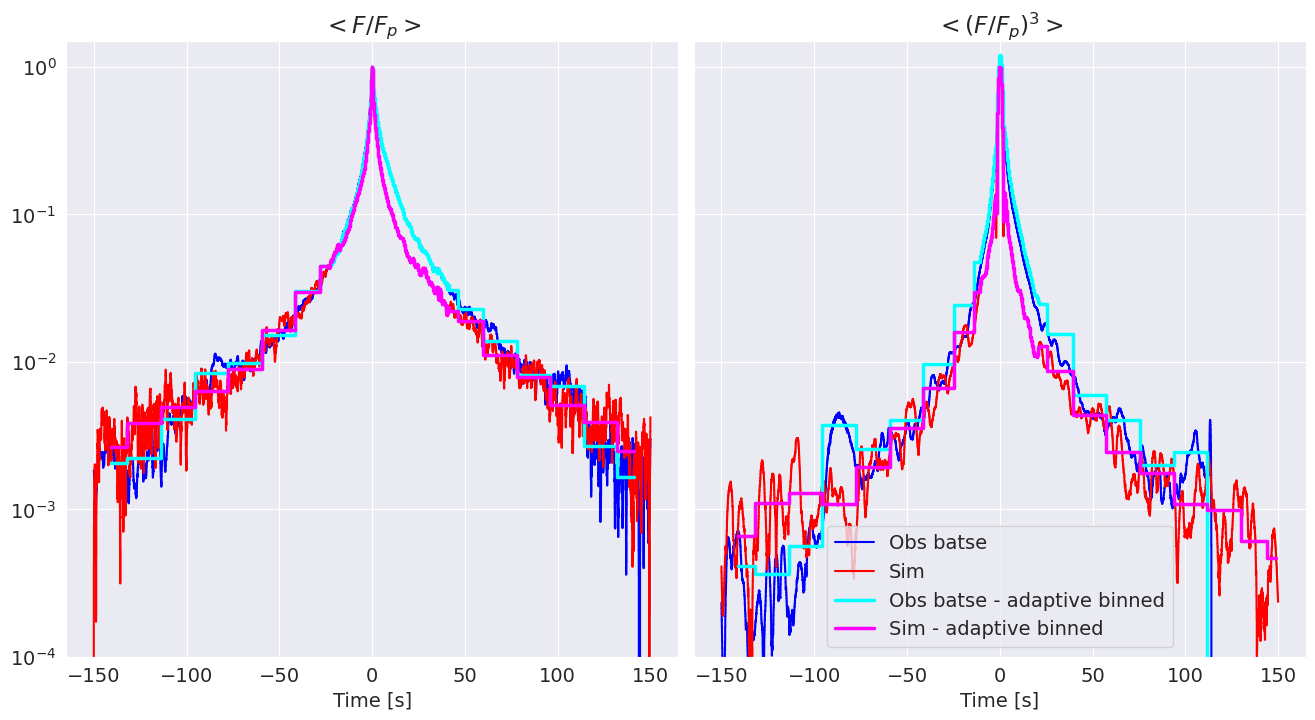

In [ ]:
times = np.linspace(-150,150,4686)
times_tot = times


avgd_profile_sim, avgd_profile_square_sim, avgd_profile_cube_sim, steps_sim, acf_sim, duration_distr_sim, sn_distr_sim = compute_all_metrics(grb_list_sim=grb_list_sim)
x_adp_sim,y_adp_sim,npts_sim = rebin_with_given_edges_fast(times_tot,avgd_profile_sim,edges_left,edges_right,stat='mean')
x_adp_sim_cube,y_adp_sim_cube,npts_sim_cube = rebin_with_given_edges_fast(times,avgd_profile_cube_sim,edges_left_cube,edges_right_cube,stat='mean')

fig,axs = plt.subplots(1, 2,figsize=(16, 8), sharex=True,sharey=True)
# remove space between subplots

fig.subplots_adjust(wspace=0.025)
axs[0].step(times, avgd_profile,color='blue')
axs[0].step(times_tot, avgd_profile_sim,color='red')
axs[0].set_yscale('log')
axs[0].set_xlabel('Time [s]')
axs[0].set_title(r'$<F/F_p>$')
axs[0].set_ylim(1e-3,1)
#axs[0].set_xlim(-150,0)




axs[1].set_xlabel('Time [s]')
axs[1].set_yscale('log')
axs[1].step(times, avgd_profile_cube,color='blue',label=f'Obs {instrument}')
axs[1].step(times_tot, avgd_profile_cube_sim,color='red',label='Sim')
axs[1].set_title(r'$<(F/F_p)^3>$')
axs[1].set_ylim(1e-4,1.5)



axs[0].step(x_bins, y_bins, where='mid',label=f'Obs {instrument} - adaptive binned', color='cyan', linestyle='-',lw=2.5)
axs[0].step(x_adp_sim, y_adp_sim, where='mid',label='Sim - adaptive binned', color='magenta', linestyle='-',lw=2.5)

axs[1].step(x_bins_cube, 1.2*y_bins_cube, where='mid',label=f'Obs {instrument} - adaptive binned', color='cyan', linestyle='-',lw=2.5)
axs[1].step(x_adp_sim_cube, y_adp_sim_cube, where='mid',label='Sim - adaptive binned', color='magenta', linestyle='-',lw=2.5)

# increase font size
plt.rcParams.update({'font.size': 14})

loss_avgd = np.nanmean(np.sqrt(np.abs(np.log10(y_bins+eps_log)-np.log10(y_adp_sim+eps_log))))
loss_avgd_cube = np.nanmean(np.sqrt(np.abs(np.log10(y_bins_cube+eps_log)-np.log10(y_adp_sim_cube+eps_log))))


print('Loss average profile:',"%1.3f"%loss_avgd)
print('Loss average profile square:',"%1.3f"%loss_avgd_cube)
plt.legend()

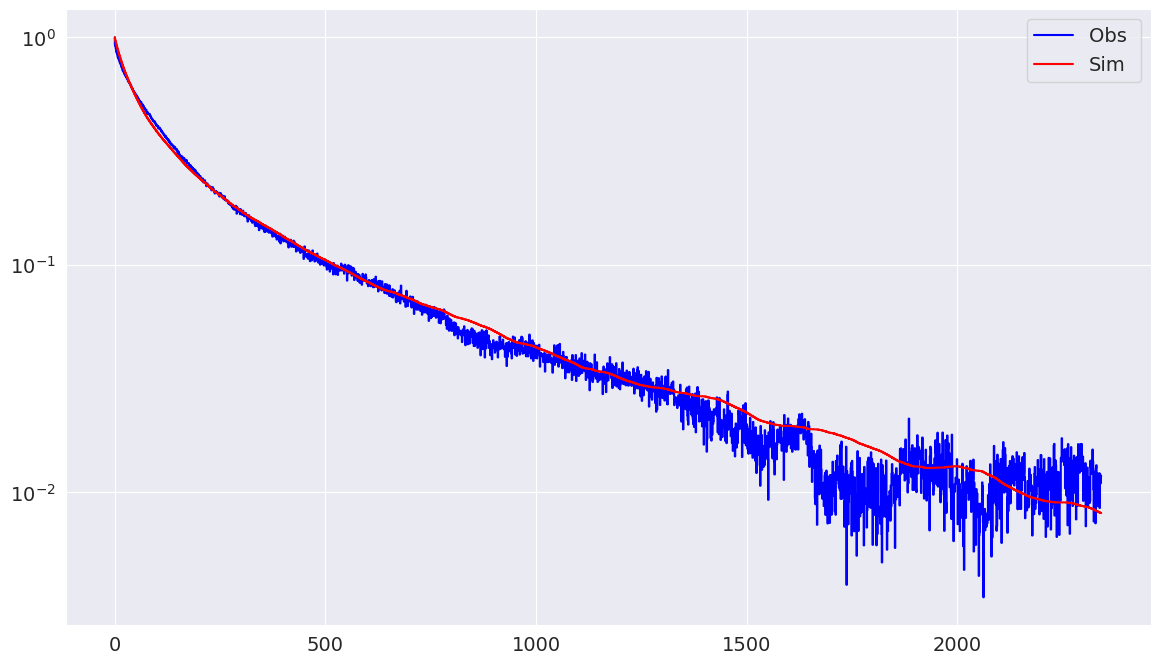

In [19]:
steps_sim, \
acf_sim  = compute_autocorrelation(grb_list=grb_list_sim,
                                            N_lim=len(grb_list_sim),
                                            t_max=t_f,
                                            bin_time=0.064,
                                            mode='scipy',
                                            compute_rms=False)
loss_acf = np.sqrt(np.sum((acf_real - acf_sim)**2))
plt.figure(figsize=(14,8))
plt.step(steps_sim, acf_real,label='Obs ',color='blue')
plt.step(steps_sim, acf_sim,label='Sim',color='red')
plt.yscale('log')
plt.legend()

KS test p-value: 6.729e-02
loss_sn 0.0


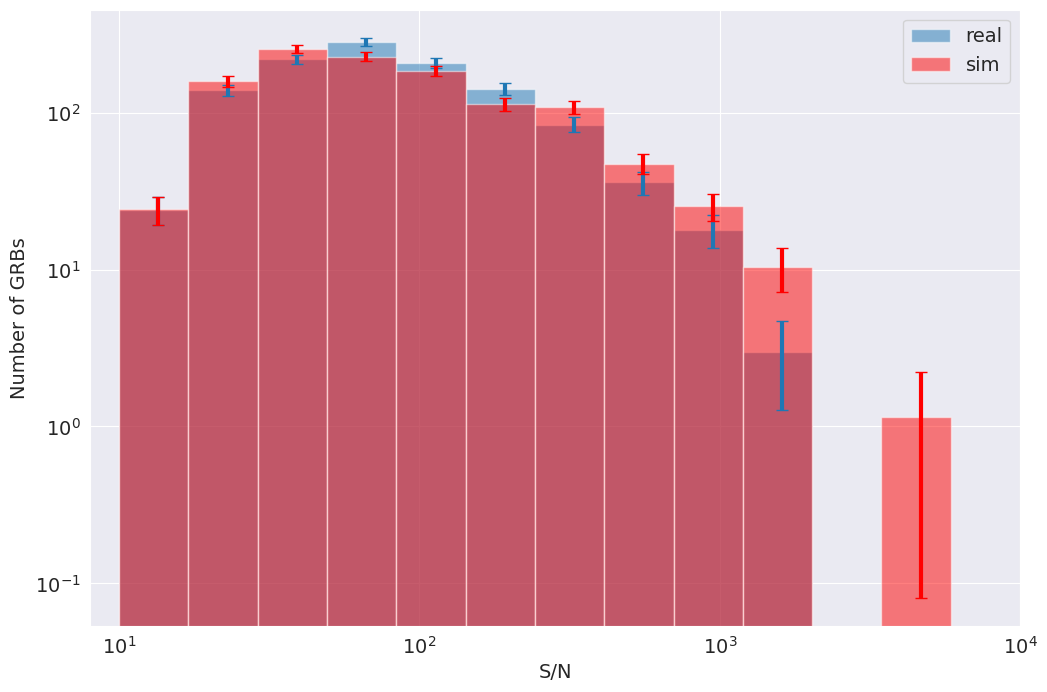

In [ ]:
dist_real_SNlist= np.array([evaluateGRB_SN(grb.times,grb.counts,grb.errs,grb.t90,t90_frac,0.064,filter=True)[0] for grb in grb_list_real])
dist_sim_SNlist= np.array([evaluateGRB_SN(grb.times,grb.counts,grb.errs,grb.t90,t90_frac,0.064,filter=True)[0] for grb in grb_list_sim])


fig, ax = plt.subplots(1, 1, figsize=(12, 8))
bins = np.logspace(1, 4, 14)
n_real,bins = np.histogram(dist_real_SNlist,bins=bins)
n_sim,_ = np.histogram(dist_sim_SNlist,bins=bins)
n_sim = np.array([float(n) for n in n_sim])
n_sim *= (np.sum(n_real)/np.sum(n_sim))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('S/N')
plt.ylabel('Number of GRBs')
widths = np.diff(bins)
bin_centers = 0.5*(bins[1:]+bins[:-1])
plt.bar(bins[:-1],n_real,width=widths,alpha=0.5,label='real',align='edge')
plt.errorbar(bin_centers,n_real,yerr=np.sqrt(n_real),ls='',capsize=4,lw=3)
plt.bar(bins[:-1],n_sim,width=widths,label='sim',alpha=0.5,align='edge',color='r')
plt.errorbar(bin_centers,n_sim,yerr=np.sqrt(n_sim),ls='',capsize=4,color='r',lw=3)
pvalue_sn = two_pop_test(dist_real_SNlist, dist_sim_SNlist, mode='KS')
plt.xlim(8, 10000)
print('KS test p-value:',"%1.3e"%pvalue_sn)
loss_sn = loss_compatibility_test(pvalue_sn)
print('loss_sn',loss_sn)
plt.legend()

In [21]:
duration      = [ evaluateDuration20(times=grb.times, 
                                           counts=grb.counts,
                                           filter=True,
                                           t90=grb.t90,
                                           t90_frac=t90_frac,
                                           bin_time=0.064)[0] for grb in grb_list_real]

duration_sim = [ evaluateDuration20(times=grb.times, 
                                           counts=grb.counts,
                                           filter=True,
                                           t90=grb.t90,
                                           t90_frac=t90_frac,
                                           bin_time=0.064)[0] for grb in grb_list_sim]

dur_distr     = compute_kde_log_duration(duration)
dur_distr_sim = compute_kde_log_duration(duration_sim)

loss_duration = np.sqrt(np.sum((dur_distr - dur_distr_sim)**2))
print('Loss duration:',"%1.3f"%loss_duration)


Loss duration: 3.044


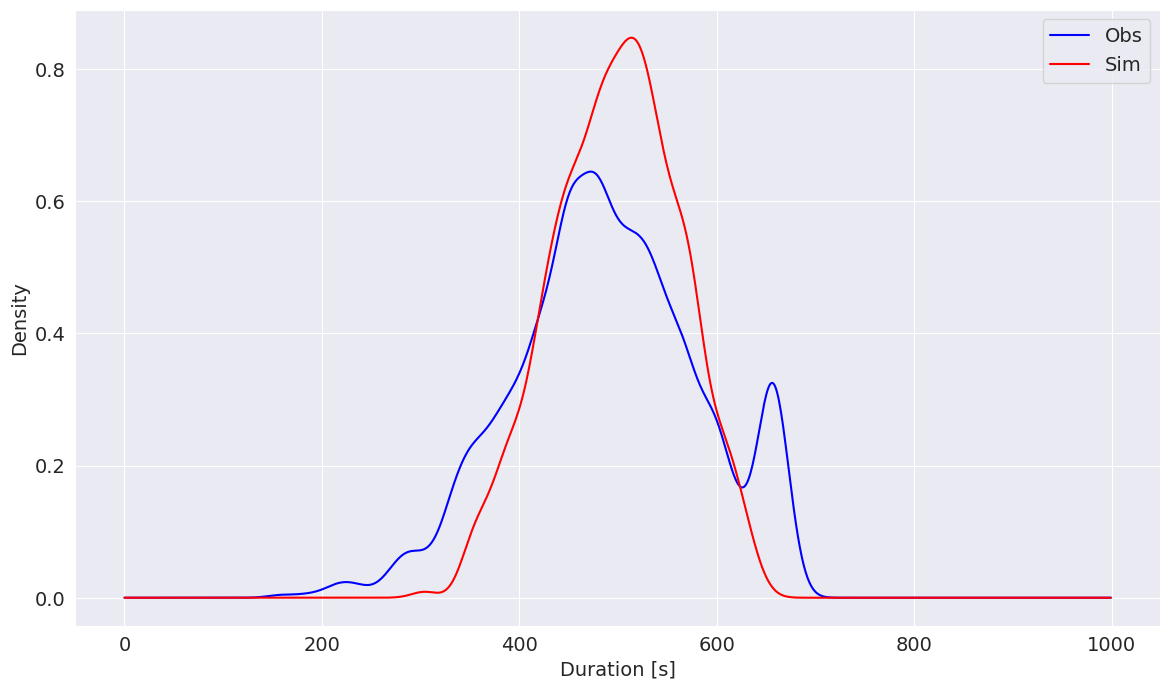

In [22]:
plt.figure(figsize=(14,8))
plt.plot(dur_distr,c='b',label='Obs')
plt.plot(dur_distr_sim,c='r',label='Sim')
plt.xlabel('Duration [s]')
plt.ylabel('Density')
plt.legend()

In [23]:
print('Losses:')
print('Average peak profile:',"%1.3f"%loss_avgd)
print('Average peak profile cube:',"%1.3f"%loss_avgd_cube)
print('ACF:',"%1.3f"%loss_acf)
print('S/N:',"%1.3f"%loss_sn)
print('Duration:',"%1.3f"%loss_duration)
print('Total loss:',"%1.3f"%((loss_avgd+loss_avgd_cube+loss_sn+loss_acf+loss_duration)/5))

Losses:
Average peak profile: 0.340
Average peak profile cube: 0.495
ACF: 0.386
S/N: 0.000
Duration: 3.044
Total loss: 0.853


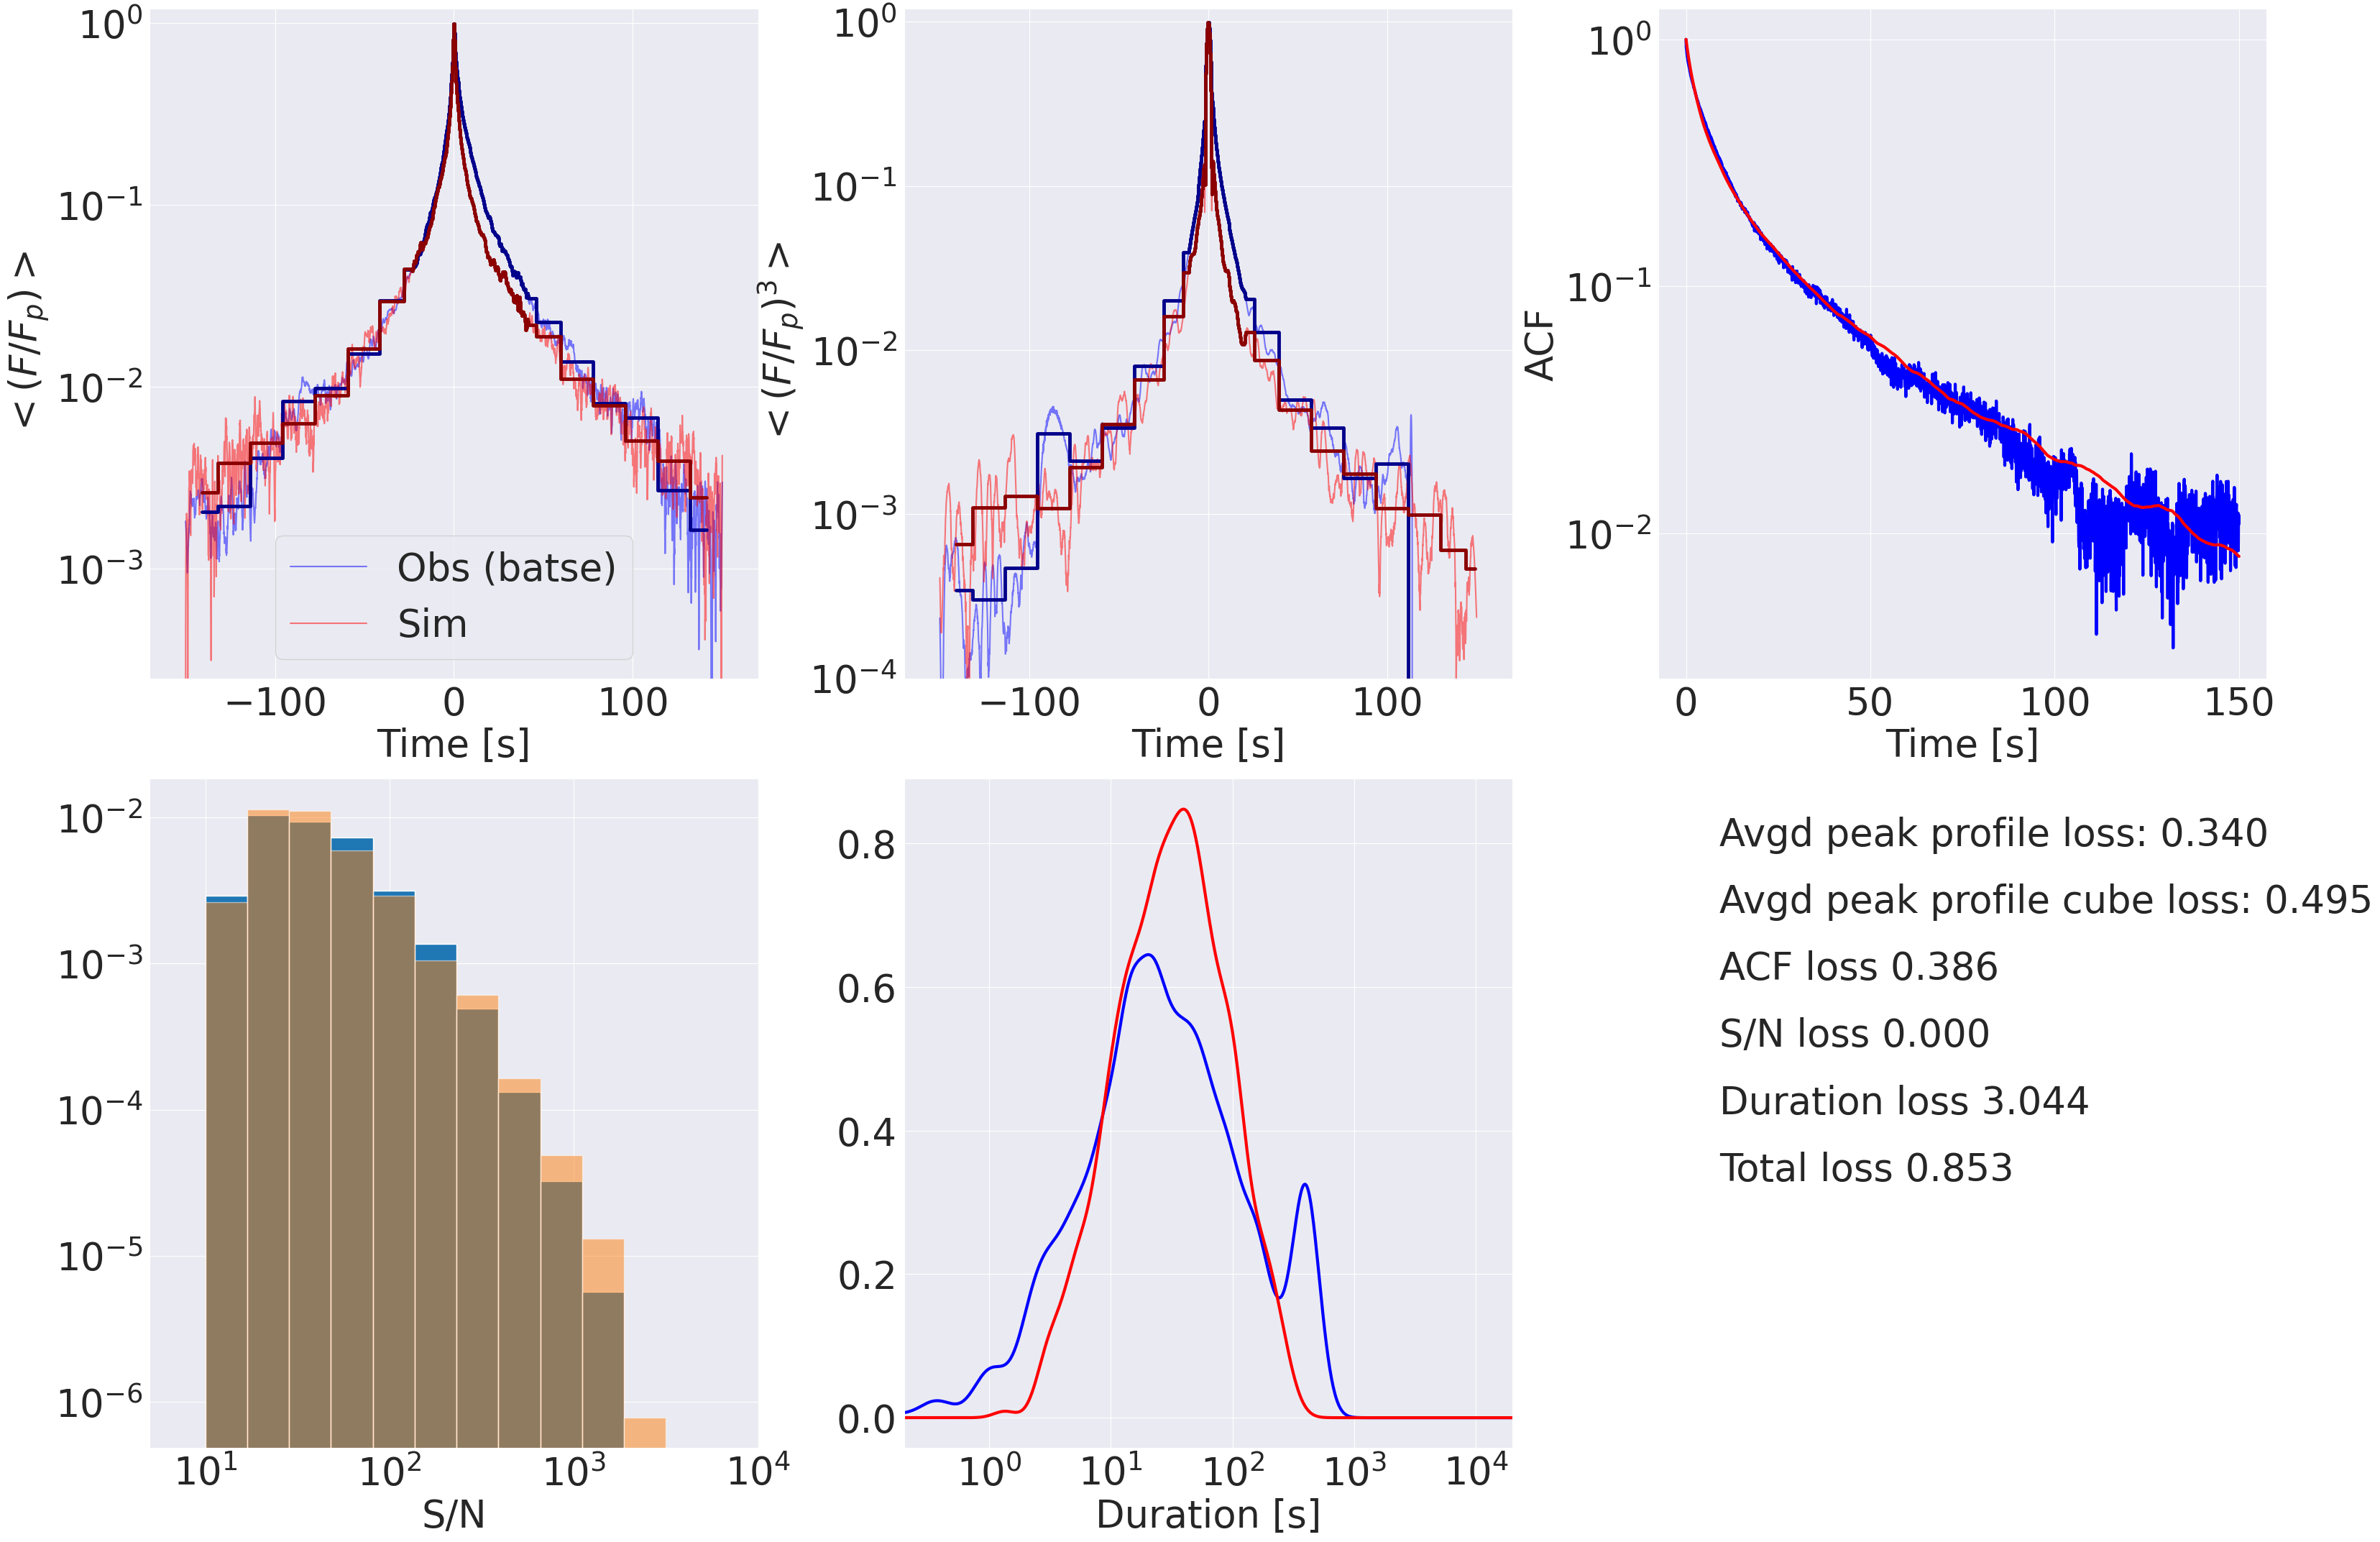

In [ ]:
# figure with 5 panels for each loss
fig, axs = plt.subplots(2, 3, figsize=(38, 26))
# add space between subplots
fig.subplots_adjust(hspace=0.15,wspace=0.24)

fontsize = 38
axs[0,0].plot(times, avgd_profile, label=f'Obs ({instrument})', color='blue', alpha=0.5)
axs[0,0].plot(times_tot, avgd_profile_sim, label='Sim', color='red', alpha=0.5)
axs[0,0].set_yscale('log')
axs[0,0].set_xlabel('Time [s]',size=fontsize)
axs[0,0].set_ylabel(r'$<(F/F_p)>$',size=fontsize)
axs[0,0].set_ylim(2.5e-4,1.2)
axs[0,0].set_xlim(-170,170)
#axs[0,0].set_title('Average profile')

axs[0,0].legend(fontsize=fontsize)
axs[0,0].step(x_bins, y_bins, where='mid',label=f'Obs ({instrument}) - adaptive binned', color='darkblue', linestyle='-',lw=3.5)
axs[0,0].step(x_adp_sim, y_adp_sim, where='mid',label='Sim - adaptive binned', color='darkred', linestyle='-',lw=3.5)

axs[0,1].plot(times, avgd_profile_cube, label=f'Obs ({instrument})', color='blue',alpha=0.5)
axs[0,1].plot(times_tot, avgd_profile_cube_sim, label='Sim', color='red',alpha=0.5)
axs[0,1].set_yscale('log')
axs[0,1].set_xlabel('Time [s]',size=fontsize)
axs[0,1].set_ylabel(r'$<(F/F_p)^3>$',size=fontsize)
axs[0,1].set_ylim(1e-4,1.2)
axs[0,1].set_xlim(-170,170)

axs[0,1].step(x_bins_cube, y_bins_cube, where='mid',label=f'Obs {instrument} - adaptive binned', color='darkblue', linestyle='-',lw=3.5)
axs[0,1].step(x_adp_sim_cube, y_adp_sim_cube, where='mid',label='Sim - adaptive binned', color='darkred', linestyle='-',lw=3.5)

times_acf = np.linspace(0, 150, len(acf_real))
axs[0,2].plot(times_acf, acf_real, label=f'Obs {instrument} ', color='blue',lw=3)
axs[0,2].plot(times_acf, acf_sim, label='Sim', color='red', lw=3)

axs[0,2].set_xlabel('Time [s]',size=fontsize)
axs[0,2].set_ylabel('ACF',size=fontsize)
axs[0,2].set_yscale('log')

#axs[1,0].set_title('ACF')
bins = np.logspace(1, 3.5, 12)
axs[1,0].hist(dist_real_SNlist, bins=bins, alpha=1.0, density=True, label='real')
axs[1,0].hist(dist_sim_SNlist, bins=bins, alpha=0.5, density=True, label='sim')

axs[1,0].set_xlabel('S/N',size=fontsize)
axs[1,0].set_xlim(5,1e4)
axs[1,0].set_xscale('log')
axs[1,0].set_yscale('log')

x_grid = np.linspace(-2,    5, 1000)
axs[1,1].plot(10**x_grid,dur_distr, label=f'Obs ({instrument})', color='blue',lw=3)
axs[1,1].plot(10**x_grid,dur_distr_sim, label='Sim', color='red', lw=3)
axs[1,1].set_xlabel('Duration [s]',size=fontsize)
axs[1,1].set_xscale('log')
axs[1,1].set_xlim(2e-1,2e4)
# supress axs[1,2]
axs[1,2].axis('off')


axs[1,2].text(0.1,0.9,'Avgd peak profile loss: %1.3f'%loss_avgd,fontsize=fontsize)
axs[1,2].text(0.1,0.8,'Avgd peak profile cube loss: %1.3f'%loss_avgd_cube,fontsize=fontsize)
axs[1,2].text(0.1,0.7,'ACF loss %1.3f'%loss_acf,fontsize=fontsize)
axs[1,2].text(0.1,0.6,'S/N loss %1.3f'%loss_sn,fontsize=fontsize)
axs[1,2].text(0.1,0.5,'Duration loss %1.3f'%loss_duration,fontsize=fontsize)
axs[1,2].text(0.1,0.4,'Total loss %1.3f'%((loss_avgd+loss_avgd_cube+loss_sn+loss_acf+loss_duration)/5),fontsize=fontsize)

avgd_flux = np.loadtxt('avgd_flux_correct.txt')
avgd_flux_cube_manu = np.loadtxt('/astrodata/romain/geneticgrbs_v2-main/genetic_algorithm/avgd_flux_cube.txt')
avgd_flux_cube_correct = np.loadtxt('avgd_flux_cube_correct.txt')

# increase font size of ticks
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

os.makedirs(f'{instrument}_results',exist_ok=True)
fig.savefig(f'{instrument}_results/metrics_obs_{instrument}_SpeWie4.pdf', bbox_inches='tight')

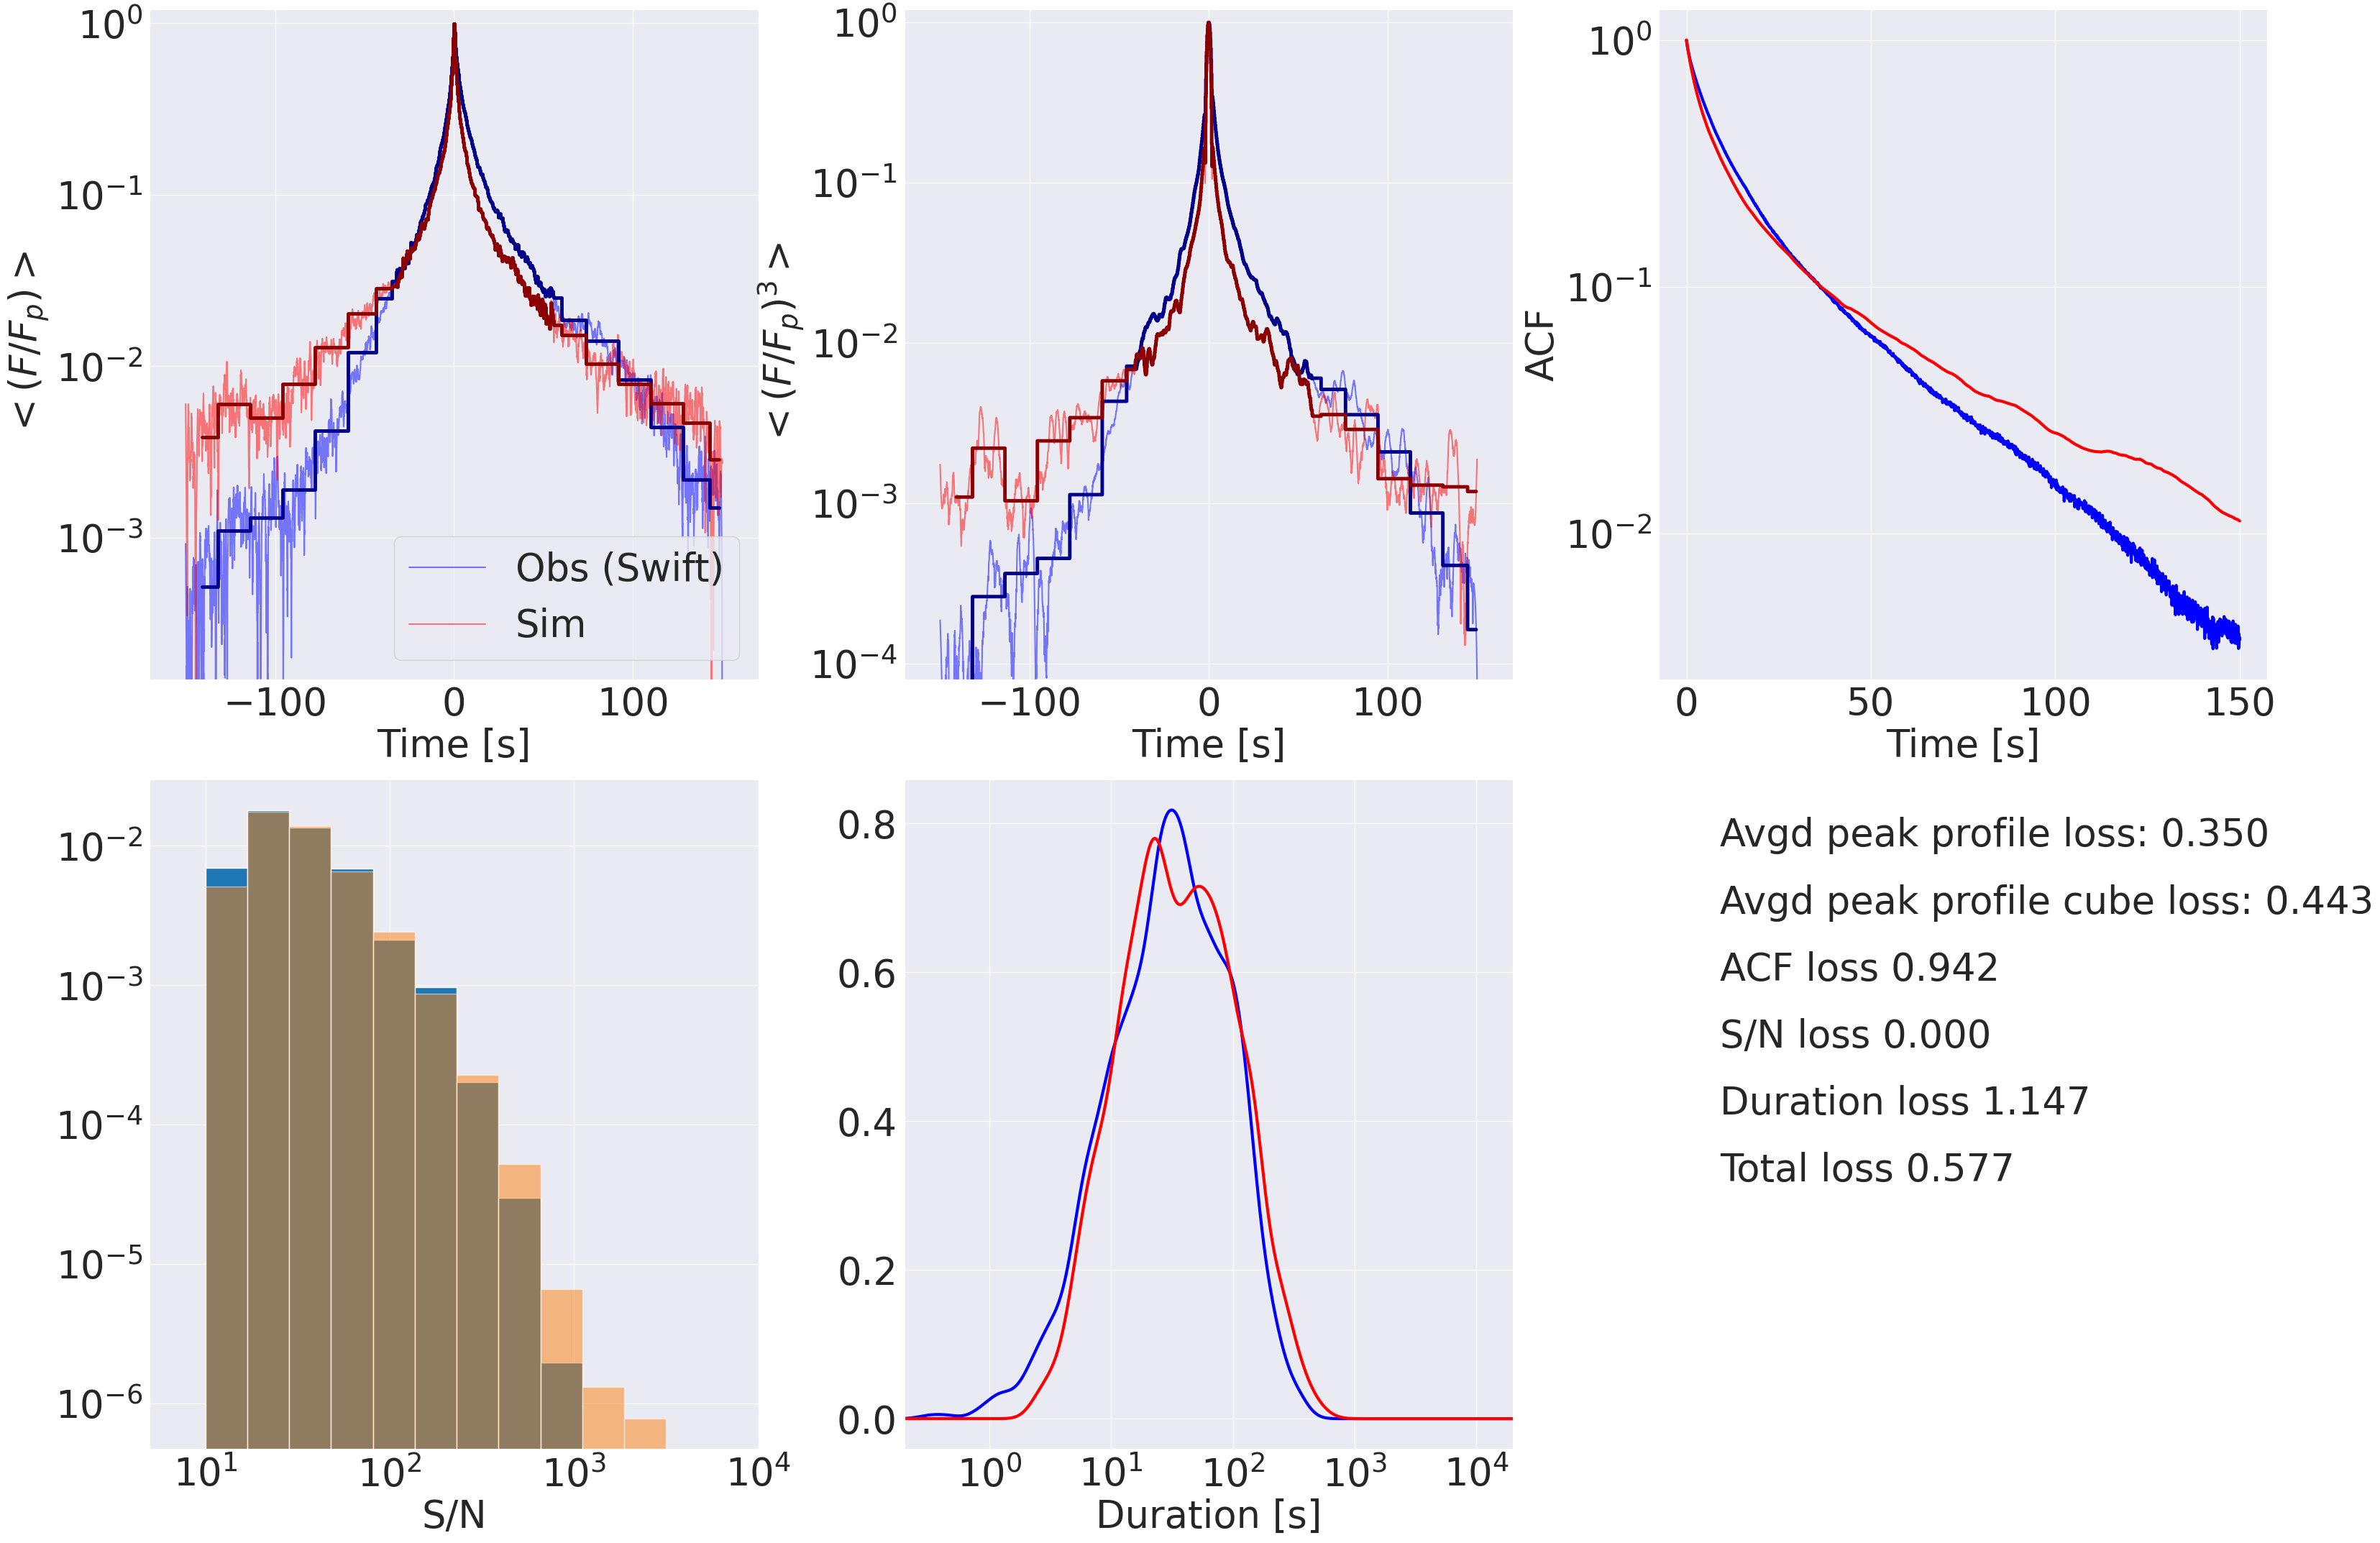

In [ ]:
# figure with 5 panels for each loss
fig, axs = plt.subplots(2, 3, figsize=(38, 26))
# add space between subplots
fig.subplots_adjust(hspace=0.15,wspace=0.24)

fontsize = 38
axs[0,0].plot(times, avgd_profile, label='Obs (Swift)', color='blue', alpha=0.5)
axs[0,0].plot(times_tot, avgd_profile_sim, label='Sim', color='red', alpha=0.5)
axs[0,0].set_yscale('log')
axs[0,0].set_xlabel('Time [s]',size=fontsize)
axs[0,0].set_ylabel(r'$<(F/F_p)>$',size=fontsize)
axs[0,0].set_ylim(1.5e-4,1.2)
axs[0,0].set_xlim(-170,170)
#axs[0,0].set_title('Average profile')

axs[0,0].legend(fontsize=fontsize)
axs[0,0].step(x_bins, y_bins, where='mid',label='Obs (Swift) - adaptive binned', color='darkblue', linestyle='-',lw=3.5)
axs[0,0].step(x_adp_sim, y_adp_sim, where='mid',label='Sim - adaptive binned', color='darkred', linestyle='-',lw=3.5)

axs[0,1].plot(times, avgd_profile_cube, label='Obs (Swift)', color='blue',alpha=0.5)
axs[0,1].plot(times_tot, avgd_profile_cube_sim, label='Sim', color='red',alpha=0.5)
axs[0,1].set_yscale('log')
axs[0,1].set_xlabel('Time [s]',size=fontsize)
axs[0,1].set_ylabel(r'$<(F/F_p)^3>$',size=fontsize)
axs[0,1].set_ylim(8e-5,1.2)
axs[0,1].set_xlim(-170,170)

axs[0,1].step(x_bins_cube, y_bins_cube, where='mid',label=f'Obs {instrument} - adaptive binned', color='darkblue', linestyle='-',lw=3.5)
axs[0,1].step(x_adp_sim_cube, y_adp_sim_cube, where='mid',label='Sim - adaptive binned', color='darkred', linestyle='-',lw=3.5)

times_acf = np.linspace(0, 150, len(acf_real))
axs[0,2].plot(times_acf, acf_real, label=f'Obs {instrument} ', color='blue',lw=3)
axs[0,2].plot(times_acf, acf_sim, label='Sim', color='red', lw=3)

axs[0,2].set_xlabel('Time [s]',size=fontsize)
axs[0,2].set_ylabel('ACF',size=fontsize)
axs[0,2].set_yscale('log')

#axs[1,0].set_title('ACF')
bins = np.logspace(1, 3.5, 12)
axs[1,0].hist(dist_real_SNlist, bins=bins, alpha=1.0, density=True, label='real')
axs[1,0].hist(dist_sim_SNlist, bins=bins, alpha=0.5, density=True, label='sim')

axs[1,0].set_xlabel('S/N',size=fontsize)
axs[1,0].set_xlim(5,1e4)
axs[1,0].set_xscale('log')
axs[1,0].set_yscale('log')

x_grid = np.linspace(-2,    5, 1000)
axs[1,1].plot(10**x_grid,dur_distr, label='Obs (Swift)', color='blue',lw=3)
axs[1,1].plot(10**x_grid,dur_distr_sim, label='Sim', color='red', lw=3)
axs[1,1].set_xlabel('Duration [s]',size=fontsize)
axs[1,1].set_xscale('log')
axs[1,1].set_xlim(2e-1,2e4)
# supress axs[1,2]
axs[1,2].axis('off')


axs[1,2].text(0.1,0.9,'Avgd peak profile loss: %1.3f'%loss_avgd,fontsize=fontsize)
axs[1,2].text(0.1,0.8,'Avgd peak profile cube loss: %1.3f'%loss_avgd_cube,fontsize=fontsize)
axs[1,2].text(0.1,0.7,'ACF loss %1.3f'%loss_acf,fontsize=fontsize)
axs[1,2].text(0.1,0.6,'S/N loss %1.3f'%loss_sn,fontsize=fontsize)
axs[1,2].text(0.1,0.5,'Duration loss %1.3f'%loss_duration,fontsize=fontsize)
axs[1,2].text(0.1,0.4,'Total loss %1.3f'%((loss_avgd+loss_avgd_cube+loss_sn+loss_acf+loss_duration)/5),fontsize=fontsize)

avgd_flux = np.loadtxt('avgd_flux_correct.txt')
avgd_flux_cube_manu = np.loadtxt('/astrodata/romain/geneticgrbs_v2-main/genetic_algorithm/avgd_flux_cube.txt')
avgd_flux_cube_correct = np.loadtxt('avgd_flux_cube_correct.txt')

# increase font size of ticks
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

fig.savefig(f'{instrument}_results/metrics_obs_{instrument}_SpeWie4.pdf', bbox_inches='tight')

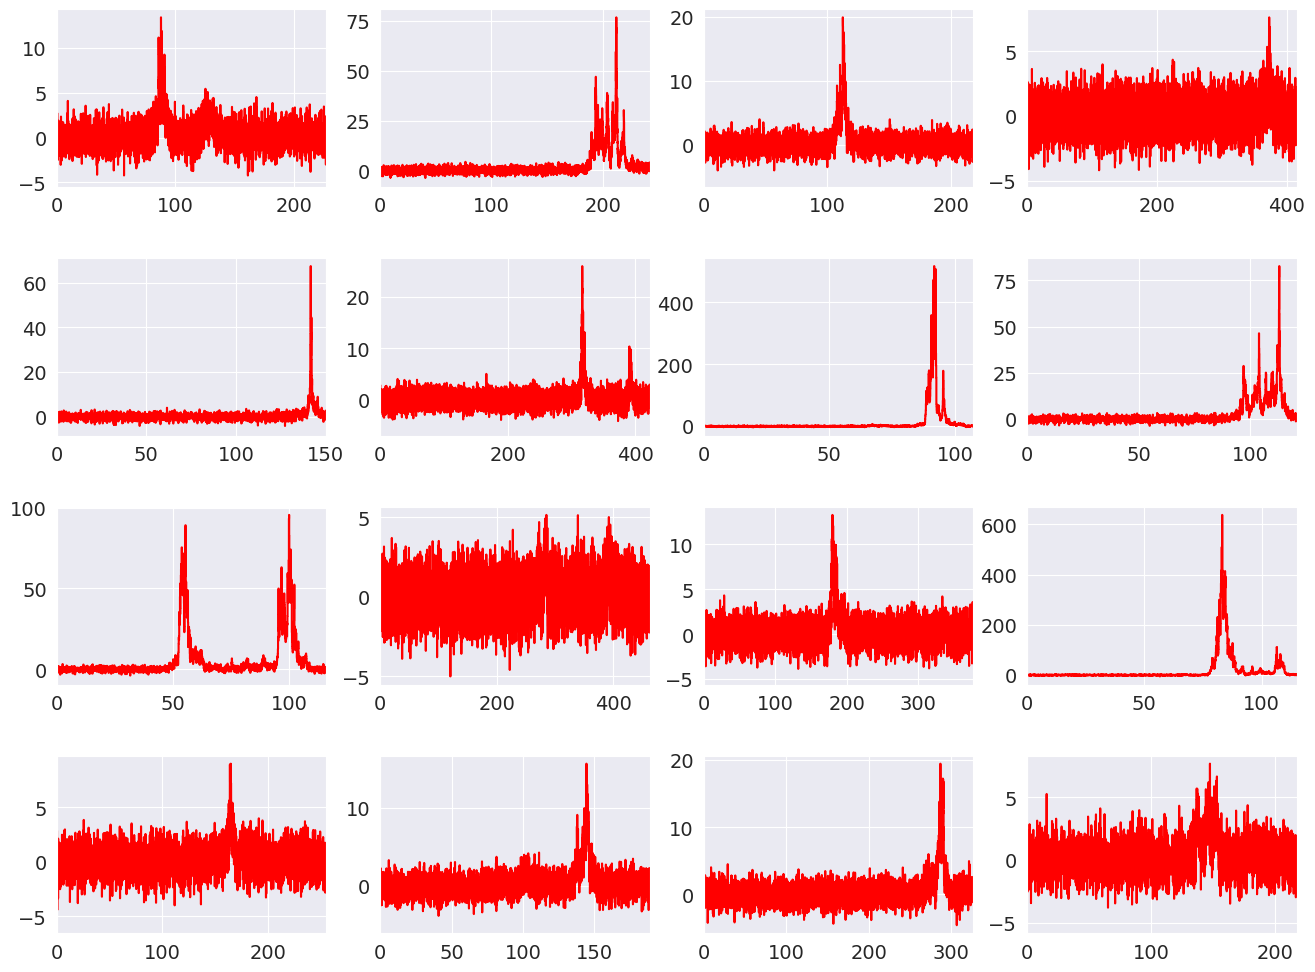

In [ ]:
# plot some grb from the model

fig, axs = plt.subplots(4, 4, figsize=(16, 12))
# increase space between subplots
fig.subplots_adjust(hspace=0.4)

for i in range(16):
    j = np.random.randint(0, len(grb_list_sim))
    axs[i//4,i%4].step(grb_list_sim[j].times, grb_list_sim[j].counts*0.064, label='Sim', color='red')
    axs[i//4,i%4].set_xlim(0,grb_list_sim[j].t90_stop+grb_list_sim[j].t90/4)

fig.savefig('lc_lomax.pdf',format='pdf')